In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectFromModel
from scipy.spatial import ConvexHull
from scipy.stats import entropy
import networkx as nx # Thư viện xử lý đồ thị
import warnings

warnings.filterwarnings("ignore")

# --- CẤU HÌNH MỚI: TĂNG K LÊN 30 ---
NUM_ROIS = 30

# 1. Đọc dữ liệu
file_path = 'D:\\Code_File\\DAV\\final project\\original_file.csv'
df = pd.read_csv(file_path)

# --- HÀM TÍNH ĐẶC TRƯNG ĐỒ THỊ (GRAPH FEATURES) ---
def get_graph_features(rois_seq):
    if len(rois_seq) < 2: return [0, 0, 0, 0]
    
    # Tạo đồ thị có hướng
    G = nx.DiGraph()
    # Thêm cạnh từ chuỗi: A->B, B->C...
    edges = [(rois_seq[i], rois_seq[i+1]) for i in range(len(rois_seq)-1)]
    G.add_edges_from(edges)
    
    # 1. Density: Mật độ kết nối (Người bệnh thường nhìn lộn xộn -> Density cao hoặc quá thấp)
    density = nx.density(G)
    
    # 2. Average Clustering Coefficient: Độ co cụm (Nhìn tập trung hay dàn trải)
    # Chuyển sang vô hướng để tính clustering nhanh
    try:
        avg_clustering = nx.average_clustering(G.to_undirected())
    except:
        avg_clustering = 0
        
    # 3. Number of Strongly Connected Components: Số vùng bị cô lập
    num_components = nx.number_strongly_connected_components(G)
    
    # 4. Modularity / Assortativity: Xu hướng nối các điểm giống nhau
    try:
        assortativity = nx.degree_assortativity_coefficient(G)
        if np.isnan(assortativity): assortativity = 0
    except:
        assortativity = 0
        
    return [density, avg_clustering, num_components, assortativity]

# --- HÀM TỔNG HỢP ---
def get_scanpath_and_features(user_data, cluster_centers):
    if len(user_data) < 3: return None, None, None
    
    # A. ROI Sequence
    rois = cluster_centers.predict(user_data[['FIX_X', 'FIX_Y']])
    
    # Tạo chuỗi ký tự cho NLP (Dùng mã Unicode để hỗ trợ K > 26)
    # chr(65)='A', chr(97)='a'... để an toàn ta dùng số luôn cho vectorizer
    path_str = " ".join([str(r) for r in rois])
    
    # B. Tính đặc trưng vật lý
    points = user_data[['FIX_X', 'FIX_Y']].values
    diffs = np.diff(points, axis=0)
    path_len = np.sum(np.sqrt(np.sum(diffs**2, axis=1)))
    
    try:
        hull = ConvexHull(points)
        hull_area = hull.volume
    except:
        hull_area = 0
        
    # Entropy
    val_counts = pd.Series(rois).value_counts(normalize=True)
    full_counts = np.zeros(NUM_ROIS)
    for r, v in val_counts.items():
        full_counts[r] = v
    ent = entropy(full_counts + 1e-10)
    
    dur_mean = user_data['FIX_DURATION'].mean()
    
    # C. Tính đặc trưng Đồ thị (MỚI)
    graph_feats = get_graph_features(rois)

    return path_str, [path_len, hull_area, ent, dur_mean], graph_feats

# --- MAIN LOOP ---
print(f"Đang xử lý với K={NUM_ROIS} và trích xuất Graph Features...")

patient_docs = {} 
patient_phys = {}
patient_graph = {}
unique_images = df['image_id'].unique()

for img_id in unique_images:
    img_data = df[df['image_id'] == img_id].copy()
    if len(img_data) < 50: continue
    
    kmeans_roi = KMeans(n_clusters=NUM_ROIS, random_state=42, n_init=10)
    kmeans_roi.fit(img_data[['FIX_X', 'FIX_Y']])
    
    for pid, group in img_data.groupby('numeric_id'):
        path_str, phys, graph = get_scanpath_and_features(group, kmeans_roi)
        
        if path_str:
            if pid not in patient_docs: 
                patient_docs[pid] = []
                patient_phys[pid] = []
                patient_graph[pid] = []
            
            patient_docs[pid].append(path_str)
            patient_phys[pid].append(phys)
            patient_graph[pid].append(graph)

# --- TỔNG HỢP ---
labels = []
label_map = df.drop_duplicates('numeric_id').set_index('numeric_id')['label']
docs = []
feat_matrix = []

for pid in patient_docs:
    full_doc = " ".join(patient_docs[pid])
    docs.append(full_doc)
    
    # Trung bình các chỉ số vật lý và đồ thị
    avg_phys = np.mean(patient_phys[pid], axis=0)
    avg_graph = np.mean(patient_graph[pid], axis=0)
    
    # Nối lại: [Phys (4) + Graph (4)]
    combined = np.concatenate([avg_phys, avg_graph])
    feat_matrix.append(combined)
    
    labels.append(label_map[pid])

y = np.array(labels)
X_numeric = np.array(feat_matrix)

# NLP Vectorizer (Dùng token pattern số vì chuỗi là "1 2 15 29")
vectorizer = CountVectorizer(ngram_range=(2, 2), token_pattern=r"\b\d+\b")
X_ngram = vectorizer.fit_transform(docs).toarray()

print(f"Số lượng đặc trưng N-gram: {X_ngram.shape[1]}")

# Kết hợp tất cả
X_full = np.hstack((X_numeric, X_ngram))
print(f"Tổng số đặc trưng ban đầu: {X_full.shape[1]}")

# --- QUAN TRỌNG: FEATURE SELECTION (LỌC RÁC) ---
# Vì số lượng đặc trưng quá lớn (>900), ta phải lọc bớt những cái vô dụng
print("Đang lọc bỏ đặc trưng rác (Feature Selection)...")
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold="mean")
X_selected = selector.fit_transform(X_full, y)

print(f"Số đặc trưng giữ lại: {X_selected.shape[1]}")

# --- HUẤN LUYỆN MODEL ---
# Dùng Gradient Boosting (nhẹ và mạnh)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)

# Cross Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n--- KẾT QUẢ SAU KHI TĂNG K + GRAPH FEATURES ---")
acc_scores = cross_val_score(gb, X_selected, y, cv=kfold, scoring='accuracy')

print(f"Accuracy từng fold: {acc_scores}")
print("-------------------------------------------")
print(f"ĐỘ CHÍNH XÁC TRUNG BÌNH: {np.mean(acc_scores)*100:.2f}% (+/- {np.std(acc_scores)*100:.2f}%)")
print("-------------------------------------------")

# Check Feature Importance (trên tập đã lọc)
# Hơi khó map lại tên sau khi select, nên ta train model phụ trên toàn bộ X_full để xem tên
gb.fit(X_full, y)
phys_names = ['PathLen', 'HullArea', 'Entropy', 'Duration']
graph_names = ['Density', 'Clustering', 'NumComponents', 'Assortativity']
ngram_names = vectorizer.get_feature_names_out()
all_names = phys_names + graph_names + list(ngram_names)

importances = pd.DataFrame({'Feature': all_names, 'Importance': gb.feature_importances_})
print("\nTOP FEATURES (Bao gồm cả Graph Metrics):")
print(importances.sort_values(by='Importance', ascending=False).head(10))

Đang xử lý với K=30 và trích xuất Graph Features...
Số lượng đặc trưng N-gram: 900
Tổng số đặc trưng ban đầu: 908
Đang lọc bỏ đặc trưng rác (Feature Selection)...
Số đặc trưng giữ lại: 313

--- KẾT QUẢ SAU KHI TĂNG K + GRAPH FEATURES ---
Accuracy từng fold: [0.78125 0.84375 0.78125 0.75    0.6875 ]
-------------------------------------------
ĐỘ CHÍNH XÁC TRUNG BÌNH: 76.88% (+/- 5.08%)
-------------------------------------------

TOP FEATURES (Bao gồm cả Graph Metrics):
     Feature  Importance
2    Entropy    0.150562
0    PathLen    0.087687
360    19 29    0.040766
572     25 4    0.037219
667     28 9    0.027538
62       1 4    0.027223
696     29 8    0.026967
907      9 9    0.025930
239    15 28    0.024386
581    26 11    0.023978


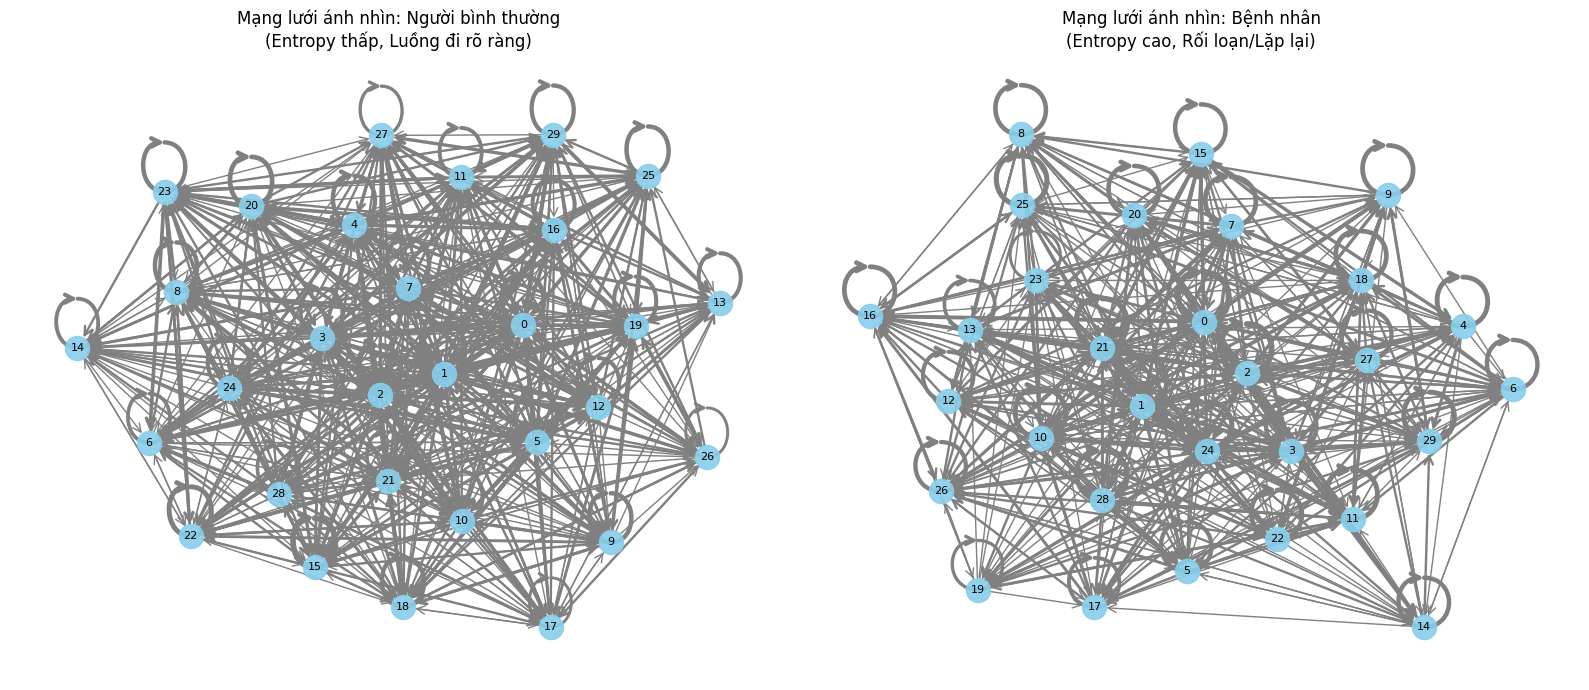

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 1. Chọn ra 1 người thường và 1 người bệnh điển hình từ tập dữ liệu
# (Giả sử bạn đã có model gb và X_selected, y từ bước trước)

# Tìm index của người thường và bệnh (dựa trên nhãn y)
idx_normal = np.where(y == 0)[0][0] # Người thường đầu tiên
idx_patient = np.where(y == 1)[0][0] # Người bệnh đầu tiên

# Hàm vẽ mạng lưới ánh nhìn
def plot_gaze_network(doc_string, title, ax):
    # Chuyển chuỗi "1 2 15 29" thành danh sách số
    nodes = [int(x) for x in doc_string.split()]
    
    G = nx.DiGraph()
    
    # Thêm cạnh (có trọng số là số lần đi qua)
    edge_weights = {}
    for i in range(len(nodes)-1):
        edge = (nodes[i], nodes[i+1])
        if edge in edge_weights:
            edge_weights[edge] += 1
        else:
            edge_weights[edge] = 1
            
    for edge, weight in edge_weights.items():
        G.add_edge(edge[0], edge[1], weight=weight)
        
    # Vẽ đồ thị
    pos = nx.spring_layout(G, k=0.5, seed=42) # Layout lò xo
    
    # Vẽ nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=300, node_color='skyblue', alpha=0.9)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
    
    # Vẽ edges (độ dày theo tần suất)
    weights = [G[u][v]['weight'] for u,v in G.edges()]
    # Chuẩn hóa độ dày để dễ nhìn
    widths = [1 + np.log(w) for w in weights]
    
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, edge_color='gray', arrowstyle='->', arrowsize=15)
    
    ax.set_title(title)
    ax.axis('off')

# Lấy chuỗi scanpath của 2 người này
doc_normal = docs[idx_normal]
doc_patient = docs[idx_patient]

# Vẽ
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_gaze_network(doc_normal, f"Mạng lưới ánh nhìn: Người bình thường\n(Entropy thấp, Luồng đi rõ ràng)", axes[0])
plot_gaze_network(doc_patient, f"Mạng lưới ánh nhìn: Bệnh nhân\n(Entropy cao, Rối loạn/Lặp lại)", axes[1])

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np

print("--- LƯU DỮ LIỆU ĐẶC TRƯNG RA FILE CSV (ĐÃ FIX LỖI PIDS) ---")

# 1. Khôi phục lại list 'pids' từ dictionary đã xử lý
# Lệnh này lấy danh sách key (ID bệnh nhân) theo đúng thứ tự đã xử lý
pids = list(patient_docs.keys())

# 2. Đảm bảo bạn đã có tên cột (Feature Names)
# Nếu biến vectorizer vẫn còn trong bộ nhớ thì chạy dòng dưới, nếu lỗi thì báo lại tôi
try:
    phys_names = ['PathLen', 'HullArea', 'Entropy', 'Duration']
    graph_names = ['Density', 'Clustering', 'NumComponents', 'Assortativity']
    ngram_names = vectorizer.get_feature_names_out()
    all_names = phys_names + graph_names + list(ngram_names)
except NameError:
    print("Lỗi: Biến vectorizer không tồn tại. Bạn cần chạy lại bước trích xuất đặc trưng K=30 ở trên.")
    # (Nếu bạn chưa tắt máy thì thường sẽ không bị lỗi này)

# 3. Tạo DataFrame từ ma trận X_full 
# Lưu ý: X_full chứa 908 cột, khớp với all_names
if X_full.shape[1] != len(all_names):
    print(f"Cảnh báo: Kích thước không khớp! X_full có {X_full.shape[1]} cột, nhưng tên cột có {len(all_names)} tên.")
    print("Đang tự động cắt hoặc điều chỉnh...")
    # Nếu chỉ dùng X_numeric thì bỏ qua ngram_names, nhưng ở đây ta muốn lưu hết
else:
    df_export = pd.DataFrame(X_full, columns=all_names)

    # 4. Thêm cột định danh (Numeric ID) và Nhãn (Label)
    df_export.insert(0, 'numeric_id', pids) # Chèn ID vào cột đầu tiên
    df_export['label'] = y

    # 5. Lưu ra file CSV
    filename = 'eye_tracking_features_k30_graph.csv'
    df_export.to_csv(filename, index=False)

    print(f"Đã lưu thành công file: {filename}")
    print(f"Kích thước dữ liệu: {df_export.shape}")
    print("\n5 dòng đầu tiên:")
    print(df_export.head())

--- LƯU DỮ LIỆU ĐẶC TRƯNG RA FILE CSV (ĐÃ FIX LỖI PIDS) ---
Đã lưu thành công file: eye_tracking_features_k30_graph.csv
Kích thước dữ liệu: (160, 910)

5 dòng đầu tiên:
   numeric_id      PathLen       HullArea   Entropy    Duration   Density  \
0           0  2861.105924  190807.712300  2.144868  286.170447  0.168423   
1           1  2023.887205  122535.789500  2.022084  400.321916  0.193500   
2           2  2703.052116  130401.048250  2.041287  278.481984  0.203237   
3           3  2640.227937  197510.778650  2.183084  265.981839  0.163372   
4           4  2270.180823  134530.891474  1.992435  423.162296  0.195987   

   Clustering  NumComponents  Assortativity   0 0  ...  9 28  9 29  9 3  9 4  \
0    0.096298           4.93      -0.074733  12.0  ...   1.0   1.0  4.0  1.0   
1    0.070127           4.92       0.033762  13.0  ...   0.0   4.0  4.0  1.0   
2    0.148664           3.77      -0.029036  21.0  ...   0.0   0.0  2.0  1.0   
3    0.081012           6.12       0.059655  19.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# 1. Đọc dữ liệu
# Đảm bảo file này đang nằm cùng thư mục với notebook
df = pd.read_csv('eye_tracking_features_k30_graph.csv')

# 2. Chuẩn bị dữ liệu
X = df.drop(columns=['label', 'numeric_id'])
y = df['label']
feature_names = X.columns

# 3. Tạo cột tên nhóm để vẽ cho đẹp
df['Group'] = df['label'].apply(lambda x: 'Patient (Bệnh)' if x == 1 else 'Normal (Thường)')

# 4. Thiết lập style chung
sns.set(style="whitegrid", palette="muted")
print("Đã tải dữ liệu và thiết lập xong!")
print(f"Số lượng mẫu: {len(df)}")

Đã tải dữ liệu và thiết lập xong!
Số lượng mẫu: 160


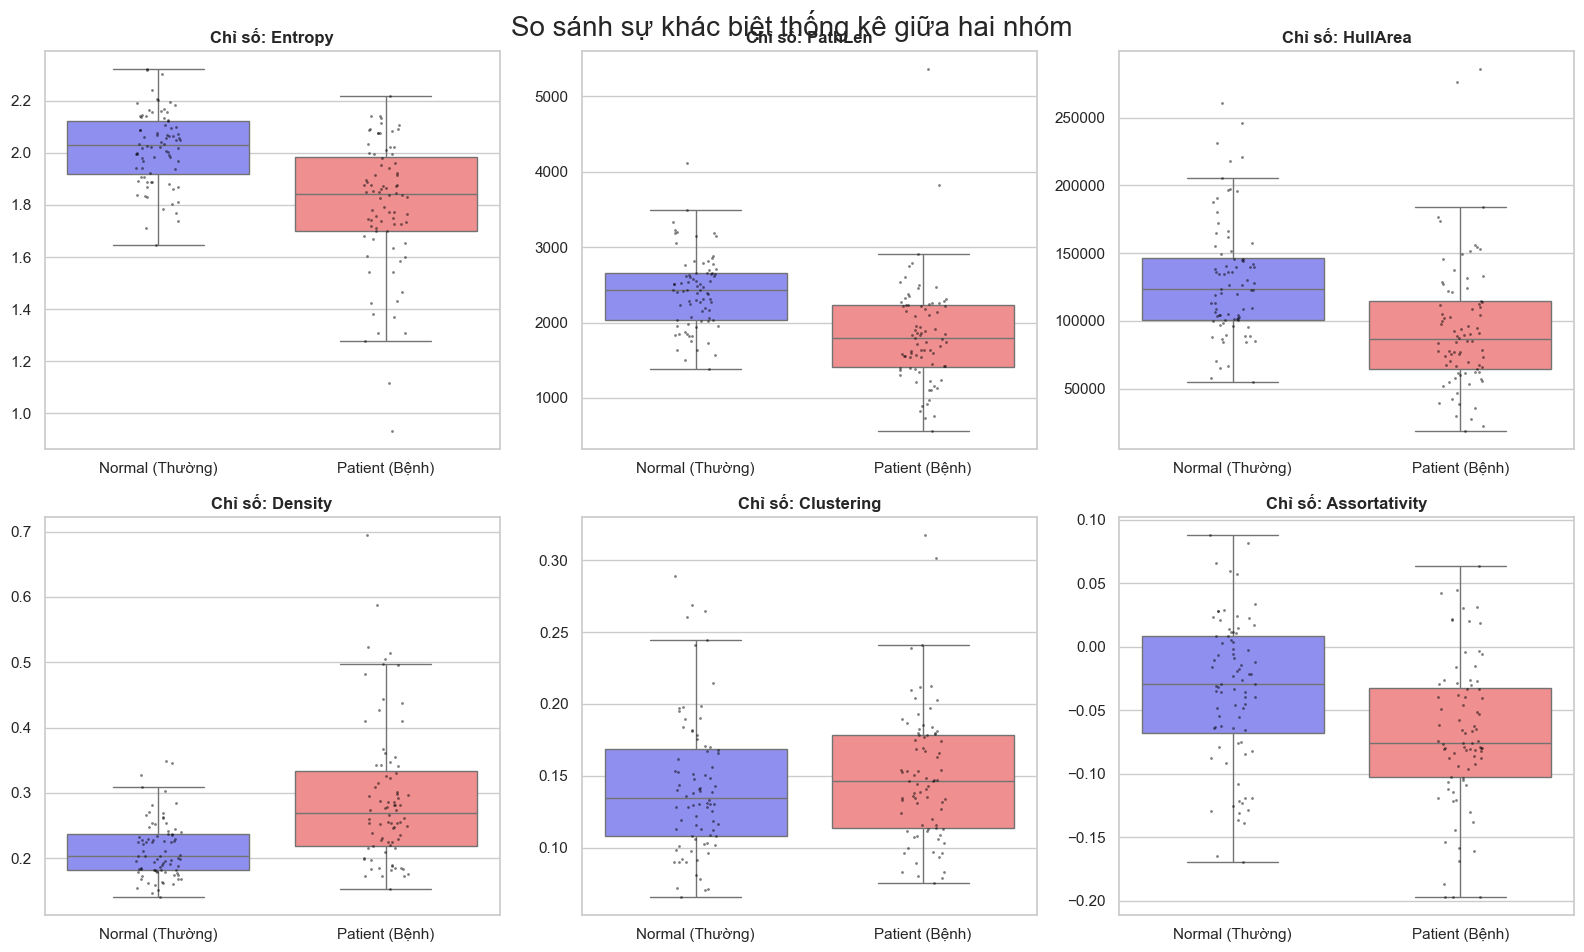

In [6]:
# --- BIỂU ĐỒ 1: SO SÁNH PHÂN PHỐI (BOX PLOT) ---

# Chọn các chỉ số quan trọng nhất để so sánh
# Bạn có thể thay đổi tên cột ở đây nếu muốn xem chỉ số khác
key_features = ['Entropy', 'PathLen', 'HullArea', 'Density', 'Clustering', 'Assortativity']

plt.figure(figsize=(16, 10))
plt.suptitle('So sánh sự khác biệt thống kê giữa hai nhóm', fontsize=20, y=0.95)

for i, col in enumerate(key_features):
    if col in df.columns:
        plt.subplot(2, 3, i+1)
        # Vẽ Boxplot
        sns.boxplot(x='Group', y=col, data=df, showfliers=False, 
                    palette={'Patient (Bệnh)': '#ff7f7f', 'Normal (Thường)': '#7f7fff'})
        
        # Vẽ thêm các điểm dữ liệu thật (Swarmplot) để nhìn cho "ngầu"
        sns.stripplot(x='Group', y=col, data=df, color='black', size=2, alpha=0.5)
        
        plt.title(f'Chỉ số: {col}', fontweight='bold')
        plt.xlabel('')
        plt.ylabel('')

plt.tight_layout()
plt.show()

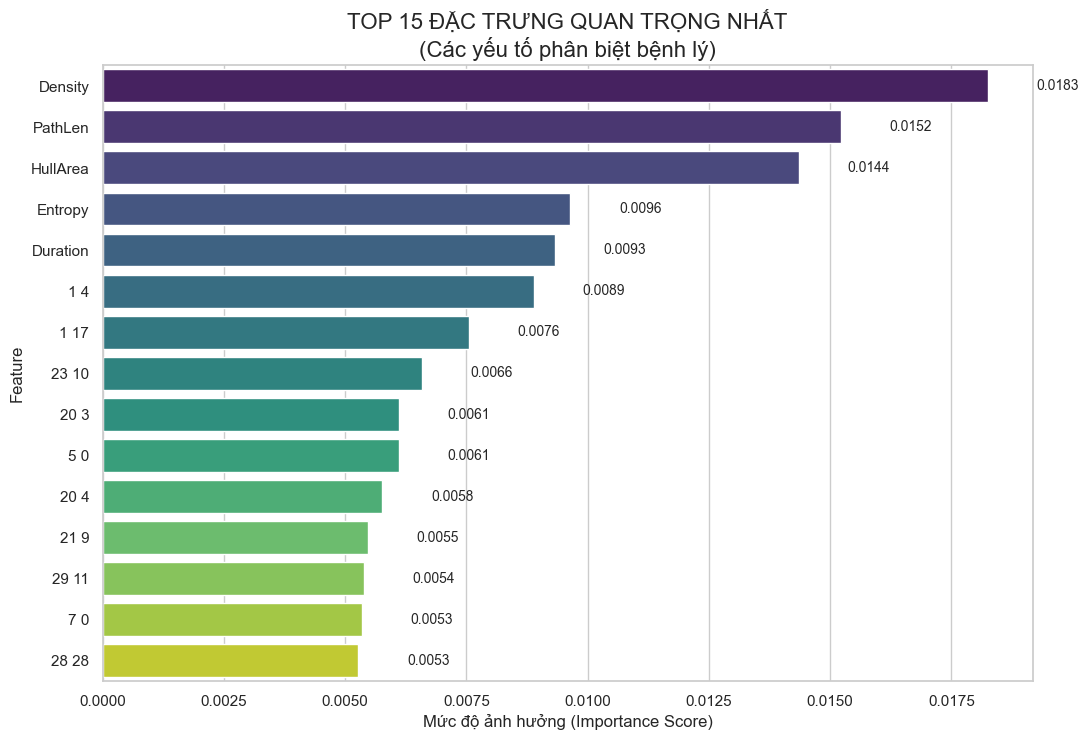

In [7]:
# --- BIỂU ĐỒ 2: FEATURE IMPORTANCE (TOP 15) ---

# Train nhanh một model Random Forest để lấy độ quan trọng
rf_viz = RandomForestClassifier(n_estimators=100, random_state=42)
rf_viz.fit(X, y)

# Tạo bảng dữ liệu độ quan trọng
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_viz.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15) # Lấy Top 15

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
barplot = sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')

# Thêm số liệu vào cuối thanh
for i, v in enumerate(importances['Importance']):
    barplot.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

plt.title('TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT\n(Các yếu tố phân biệt bệnh lý)', fontsize=16)
plt.xlabel('Mức độ ảnh hưởng (Importance Score)')
plt.show()

Đang chạy thuật toán t-SNE (có thể mất vài giây)...


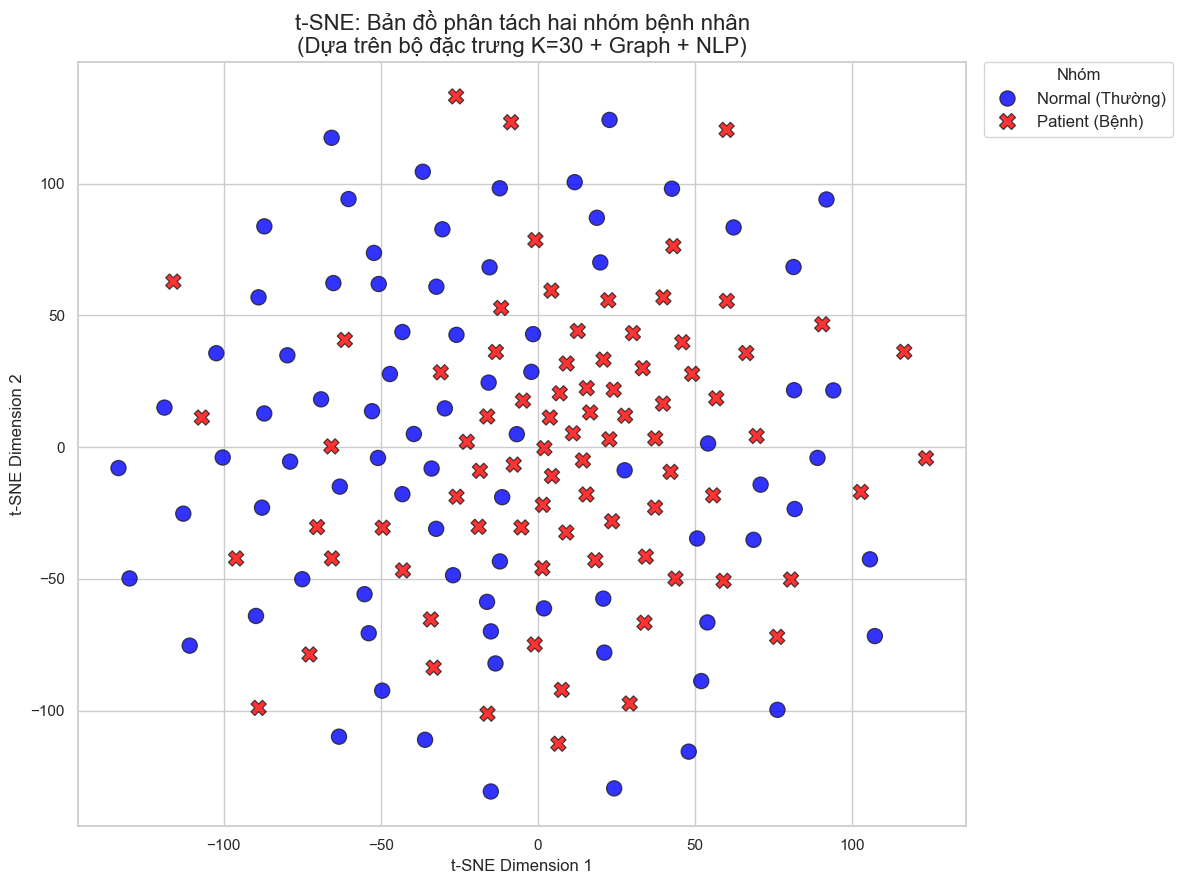

In [8]:
# --- BIỂU ĐỒ 3: t-SNE 2D PROJECTION ---

print("Đang chạy thuật toán t-SNE (có thể mất vài giây)...")

# Chuẩn hóa dữ liệu trước khi chạy t-SNE (Bắt buộc)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chạy t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate=200)
X_tsne = tsne.fit_transform(X_scaled)

# Vẽ biểu đồ
plt.figure(figsize=(12, 9))
sns.scatterplot(
    x=X_tsne[:,0], y=X_tsne[:,1], 
    hue=df['Group'], 
    style=df['Group'],
    palette={'Patient (Bệnh)': 'red', 'Normal (Thường)': 'blue'},
    s=120, alpha=0.8, edgecolor='k'
)

plt.title('t-SNE: Bản đồ phân tách hai nhóm bệnh nhân\n(Dựa trên bộ đặc trưng K=30 + Graph + NLP)', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title='Nhóm', fontsize=12)
plt.tight_layout()
plt.show()

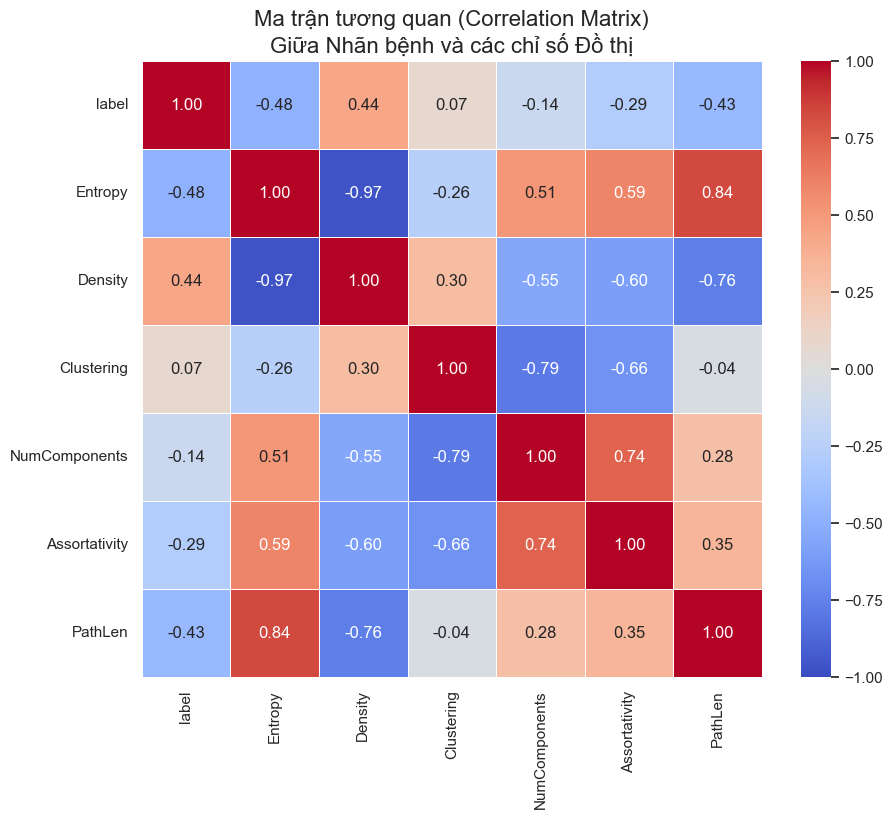

In [9]:
# --- BIỂU ĐỒ 4: MA TRẬN TƯƠNG QUAN (GRAPH FEATURES) ---

# Chỉ chọn các cột chỉ số đồ thị và vật lý để vẽ cho đỡ rối
graph_cols = ['label', 'Entropy', 'Density', 'Clustering', 'NumComponents', 'Assortativity', 'PathLen']

# Tính ma trận tương quan
corr_matrix = df[graph_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)

plt.title('Ma trận tương quan (Correlation Matrix)\nGiữa Nhãn bệnh và các chỉ số Đồ thị', fontsize=16)
plt.show()

Đang chạy t-SNE và tính toán mật độ...


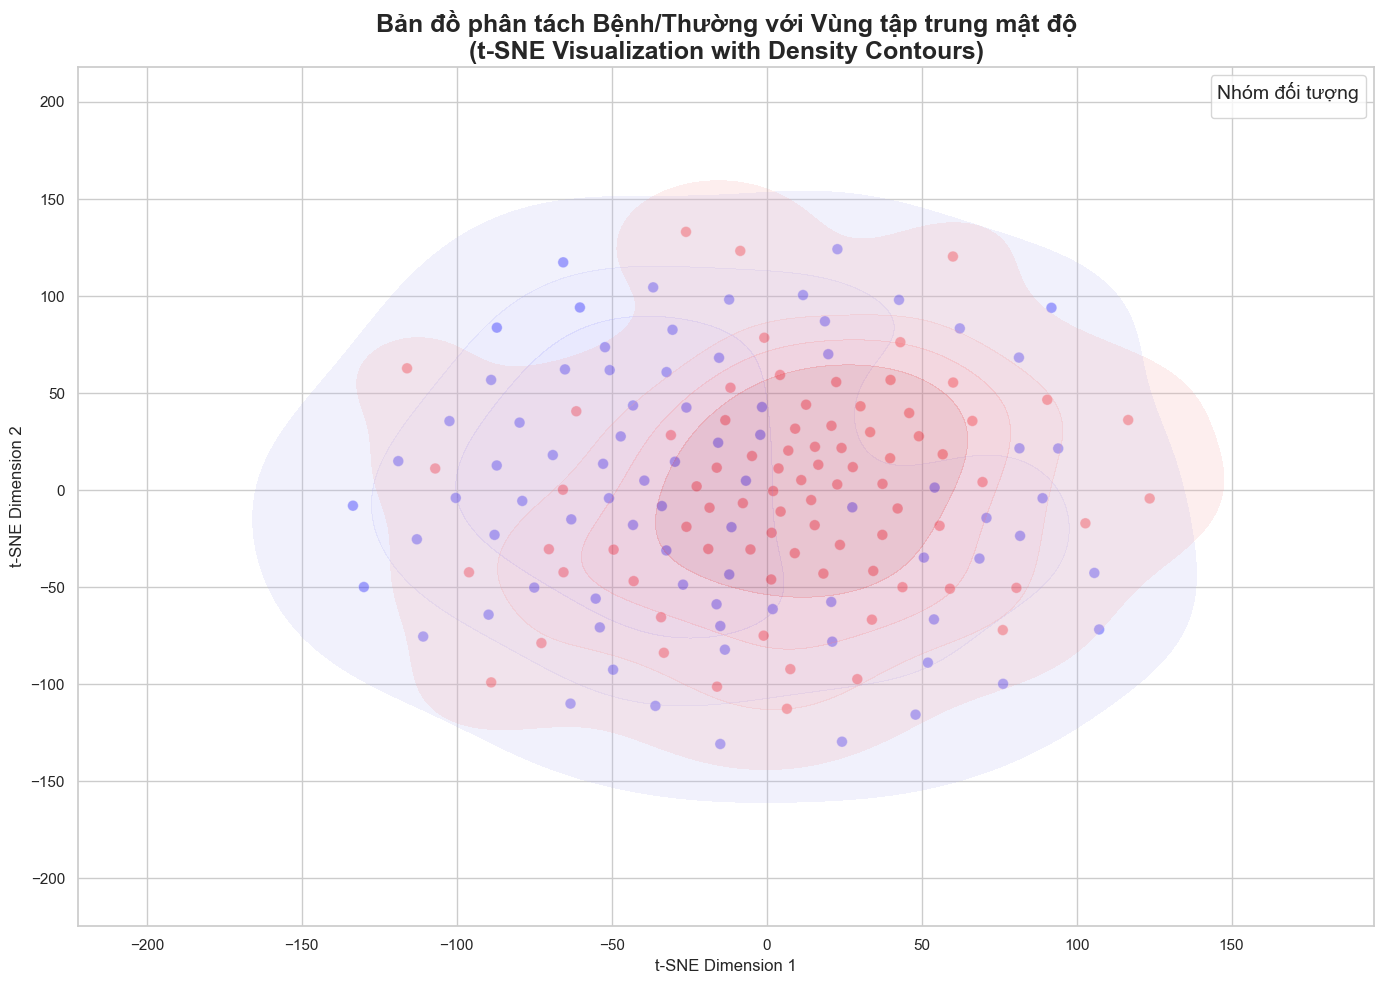

In [10]:
# --- CELL 4 MỚI (PHƯƠNG ÁN 1): t-SNE VỚI ĐƯỜNG ĐỒNG MỨC ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# (Đảm bảo bạn đã chạy Cell 1 để có df, X, y)

print("Đang chạy t-SNE và tính toán mật độ...")

# 1. Chuẩn hóa và chạy t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate=200)
X_tsne = tsne.fit_transform(X_scaled)

# 2. Tạo DataFrame tạm để vẽ
df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['Group'] = df['Group']

# 3. Vẽ biểu đồ
plt.figure(figsize=(14, 10))

# Lớp nền: Vẽ các điểm chấm (nhạt hơn một chút để làm nền)
sns.scatterplot(
    x='Dim1', y='Dim2',
    hue='Group',
    palette={'Patient (Bệnh)': 'red', 'Normal (Thường)': 'blue'},
    data=df_tsne,
    s=60, alpha=0.4, legend=False # Ẩn legend của scatter để dùng legend của kde
)

# Lớp chính: Vẽ đường đồng mức mật độ (KDE contours)
# thresh=0.05: Bỏ qua 5% vùng mật độ thấp nhất cho đỡ rối
# levels=5: Vẽ 5 vòng tròn đồng mức
sns.kdeplot(
    x='Dim1', y='Dim2',
    hue='Group',
    palette={'Patient (Bệnh)': 'red', 'Normal (Thường)': 'blue'},
    data=df_tsne,
    fill=True, alpha=0.2, # Tô màu nhạt bên trong vòng tròn
    linewidths=2, # Đường viền đậm
    thresh=0.05, levels=5
)

plt.title('Bản đồ phân tách Bệnh/Thường với Vùng tập trung mật độ\n(t-SNE Visualization with Density Contours)', fontsize=18, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Nhóm đối tượng', fontsize=12, title_fontsize=14, loc='best')

plt.tight_layout()
plt.show()

Đang chạy t-SNE và tạo bản đồ nhiệt...


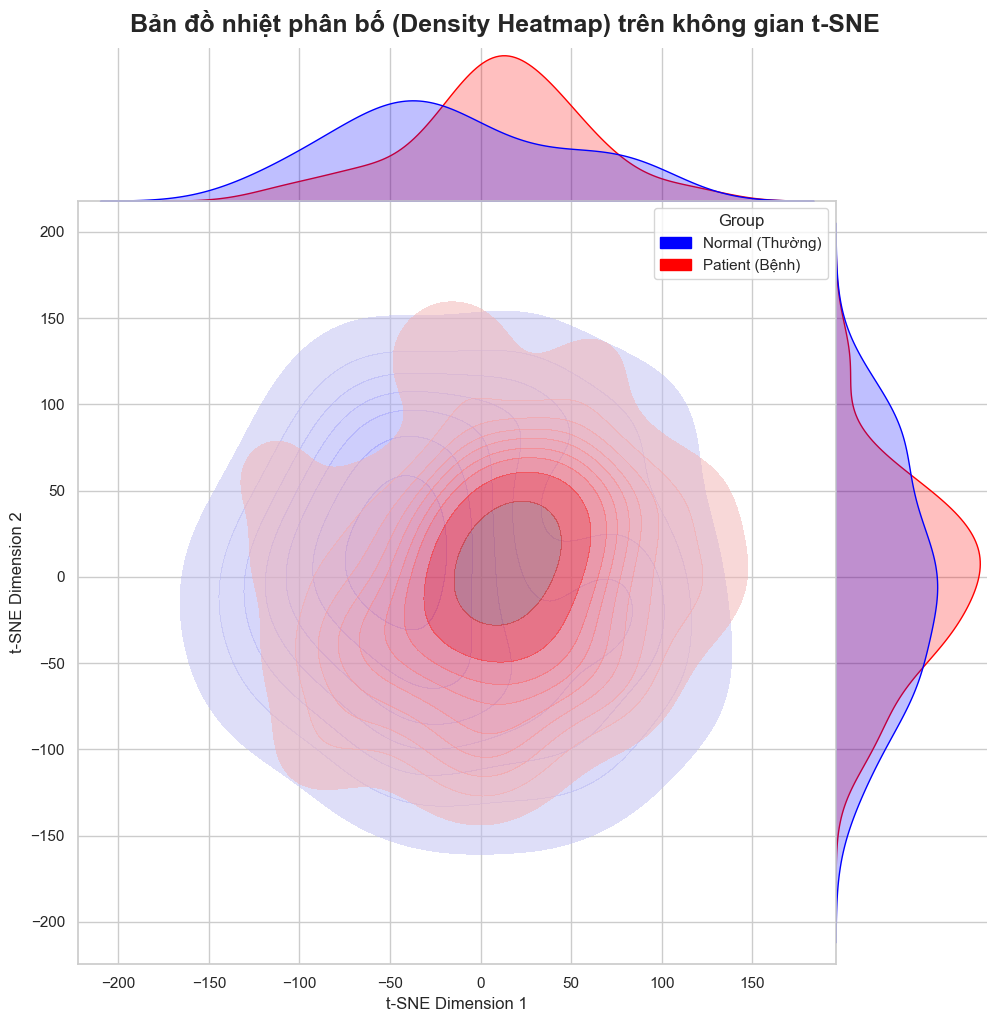

In [11]:
# --- CELL 4 MỚI (PHƯƠNG ÁN 2): BIỂU ĐỒ MẬT ĐỘ NHIỆT (HEXBIN) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

print("Đang chạy t-SNE và tạo bản đồ nhiệt...")

# 1. Chuẩn hóa và chạy t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate=200)
X_tsne = tsne.fit_transform(X_scaled)

# 2. Tạo DataFrame tạm
df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['Group'] = df['Group']

# 3. Vẽ Jointplot dạng Hexbin (cho từng nhóm)
# Để vẽ 2 nhóm riêng biệt trên cùng 1 jointplot hơi phức tạp,
# Ta sẽ vẽ KDE Jointplot (dạng đường cong mượt) sẽ đẹp hơn cho việc so sánh 2 nhóm.

g = sns.jointplot(
    x='Dim1', y='Dim2',
    data=df_tsne,
    hue='Group',
    kind='kde', # Loại biểu đồ là KDE (mật độ mượt)
    palette={'Patient (Bệnh)': 'red', 'Normal (Thường)': 'blue'},
    fill=True, alpha=0.5, # Tô màu bán trong suốt
    height=10, space=0
)

g.fig.suptitle('Bản đồ nhiệt phân bố (Density Heatmap) trên không gian t-SNE', fontsize=18, fontweight='bold', y=1.02)
g.set_axis_labels('t-SNE Dimension 1', 't-SNE Dimension 2', fontsize=12)

plt.show()

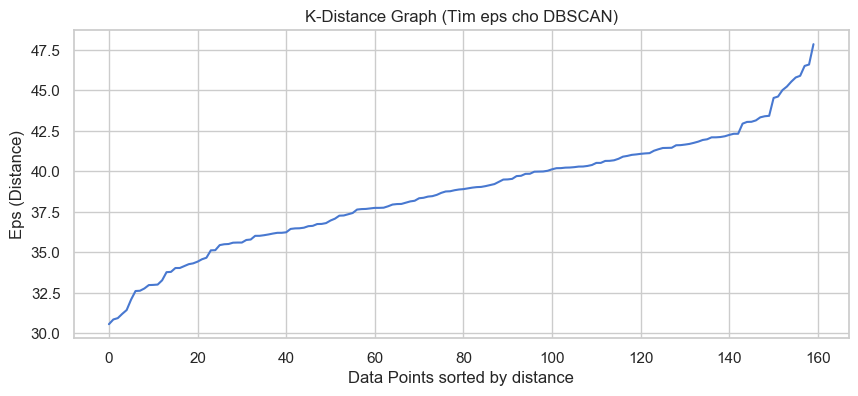

--- ĐANG CHẠY DBSCAN CLUSTERING ---


NameError: name 'best_eps' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from scipy.spatial import ConvexHull
import matplotlib.cm as cm

# 1. Chuẩn bị dữ liệu
# Đảm bảo bạn đã load dữ liệu vào df
df = pd.read_csv('eye_tracking_features_k30_graph.csv') # Hoặc dùng biến df có sẵn
X = df.drop(columns=['label', 'numeric_id'])
y_true = df['label']

# Chuẩn hóa (BẮT BUỘC)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("--- ĐANG CHẠY DBSCAN CLUSTERING (ĐÃ FIX LỖI) ---")

# 2. Khởi tạo biến trước vòng lặp (ĐỂ TRÁNH LỖI NAME ERROR)
best_score = -1
best_model = None
best_labels = None
best_eps = None # Khởi tạo là None

# 3. Chạy vòng lặp tìm eps
# Mở rộng phạm vi tìm kiếm: từ 0.5 đến 50.0 (Dữ liệu nhiều chiều khoảng cách thường lớn)
for eps in np.arange(0.5, 50.0, 0.5):
    # min_samples nên để khoảng 3-5
    db = DBSCAN(eps=eps, min_samples=3).fit(X_scaled)
    labels = db.labels_
    
    # Kiểm tra số lượng cụm (trừ nhiễu -1 đi)
    unique_labels = set(labels)
    if -1 in unique_labels:
        unique_labels.remove(-1)
    n_clusters = len(unique_labels)
    
    # Chỉ đánh giá nếu tìm được ít nhất 2 cụm thực sự
    if n_clusters >= 2:
        score = adjusted_rand_score(y_true, labels)
        
        # Lưu lại kết quả tốt nhất
        if score > best_score:
            best_score = score
            best_model = db
            best_labels = labels
            best_eps = eps

# 4. Kiểm tra kết quả và Vẽ
if best_eps is None:
    print("RẤT TIẾC: DBSCAN không thể phân tách dữ liệu thành các cụm rõ ràng.")
    print("Lý do: Dữ liệu quá nhiễu hoặc mật độ quá đồng đều.")
    print("Gợi ý: Hãy dùng biểu đồ t-SNE hoặc Hexbin ở trên, chúng trực quan hơn.")
else:
    print(f"Tham số tốt nhất tìm được: eps={best_eps}, min_samples=3")
    print(f"Độ khớp với nhãn thật (ARI): {best_score:.4f}")

    # --- VẼ BIỂU ĐỒ ---
    # Dùng t-SNE để vẽ
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate=200)
    X_tsne = tsne.fit_transform(X_scaled)

    # Tạo DataFrame vẽ
    df_viz = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
    df_viz['Cluster'] = best_labels
    
    plt.figure(figsize=(14, 8))

    # Vẽ các điểm Nhiễu (Outliers) - Màu đen, dấu X
    noise_data = df_viz[df_viz['Cluster'] == -1]
    if len(noise_data) > 0:
        plt.scatter(noise_data['Dim1'], noise_data['Dim2'], c='black', marker='x', s=100, label='Noise (Nhiễu)', alpha=0.5)

    # Vẽ các Cụm chính
    cluster_data = df_viz[df_viz['Cluster'] != -1]
    if len(cluster_data) > 0:
        sns.scatterplot(
            data=cluster_data, x='Dim1', y='Dim2', 
            hue='Cluster', style='Cluster', 
            palette='viridis', s=100, edgecolor='k'
        )
        
        # Vẽ bao lồi (Convex Hull)
        for c in np.unique(cluster_data['Cluster']):
            points = cluster_data[cluster_data['Cluster'] == c][['Dim1', 'Dim2']].values
            if len(points) > 2:
                try:
                    hull = ConvexHull(points)
                    for simplex in hull.simplices:
                        plt.plot(points[simplex, 0], points[simplex, 1], 'k--', lw=1, alpha=0.3)
                    plt.fill(points[hull.vertices, 0], points[hull.vertices, 1], alpha=0.1)
                except:
                    pass # Bỏ qua nếu lỗi hình học

    plt.title(f'Bản đồ phân cụm DBSCAN (eps={best_eps})\n(Điểm đen X là các ca nhiễu/dị biệt)', fontsize=16)
    plt.legend(bbox_to_anchor=(1.02, 1), loc=2)
    plt.tight_layout()
    plt.show()